In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [3]:
kwargs = {
    "num_workers": 1,
    "pin_memory": True,
}

# Die Trainingsdaten aus dem NIST-Datensatz müssen runtergeladen werden
train_data = torch.utils.data.DataLoader(
    datasets.MNIST(
        "data",
        train=True,
        download=True,
        transform=transforms.Compose(
            [
                transforms.ToTensor(),
                transforms.Normalize((0.1037,), (0.3081)),
            ],
        ),
    ),
    batch_size=64,
    shuffle=True,
    **kwargs,
)

test_data = torch.utils.data.DataLoader(
    datasets.MNIST(
        "data",
        train=False,
        download=True,
        transform=transforms.Compose(
            [transforms.ToTensor(), transforms.Normalize((0.1037,), (0.3081))],
        ),
    ),
    batch_size=64,
    shuffle=True,
    **kwargs,
)

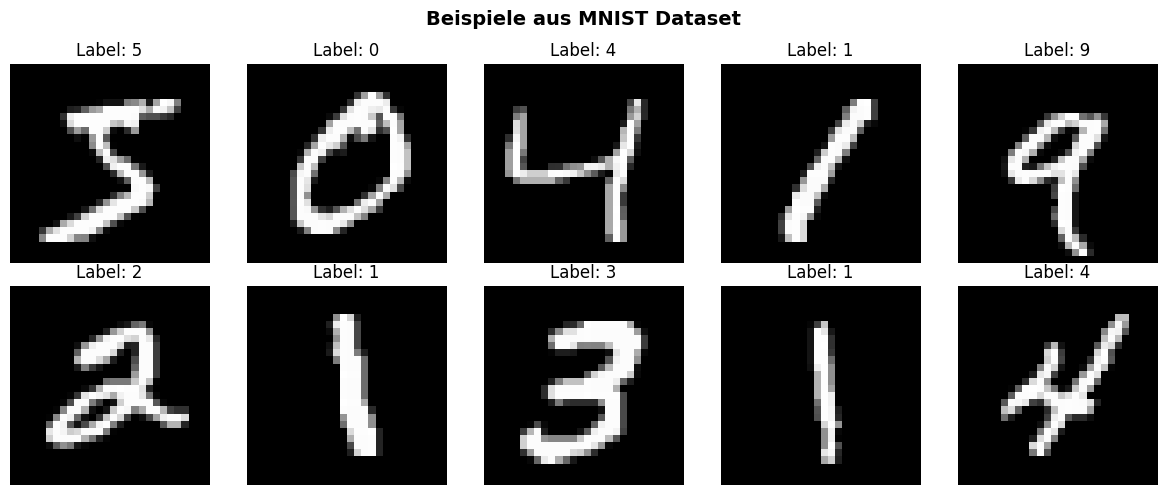

Dataset geladen!
Training: 60000 Bilder
Test: 10000 Bilder
Batch Size: 64


In [10]:
# Schauen wir uns ein paar MNIST Bilder an
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    # Ein Bild aus dem Dataset holen
    img, label = train_data.dataset[i]
    
    # Von Tensor zu NumPy für Matplotlib
    img_np = img.squeeze().numpy()
    
    ax.imshow(img_np, cmap='gray')
    ax.set_title(f'Label: {label}', fontsize=12)
    ax.axis('off')

plt.suptitle('Beispiele aus MNIST Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Dataset geladen!")
print(f"Training: {len(train_data.dataset)} Bilder")
print(f"Test: {len(test_data.dataset)} Bilder")
print("Batch Size: 64")

In [11]:
class Netz(nn.Module):
    def __init__(self):
        super(Netz, self).__init__()
        self.convl = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conf_dropout = nn.Dropout2d()
        self.fcl1 = nn.Linear(320, 60)
        self.fcl2 = nn.Linear(60, 10)

    def forward(self, x):
        x = self.convl(x)
        x = F.max_pool2d(x, 2)
        x = F.relu(x)
        x = self.conv2(x)
        x = self.conf_dropout(x)
        x = F.max_pool2d(x, 2)
        x = F.relu(x)
        x = x.view(-1, 320)
        x = F.relu(self.fcl1(x))
        x = self.fcl2(x)
        return x


model = Netz()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.8)

In [16]:
print("🧠 Netzwerk Architektur:\n")
print(model)
print("\n" + "="*60)

# Parameter zählen
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\nParameter:")
print(f"Gesamt: {total_params:,}")
print(f"Trainierbar: {trainable_params:,}")

## Layer-Größen durchrechnen
#print(f"\n📐 Dimensionen im Forward Pass:")
#print(f"   Input:        [batch, 1, 28, 28]")
#print(f"   Nach Conv1:   [batch, 10, 24, 24]  (28-5+1=24)")
#print(f"   Nach Pool1:   [batch, 10, 12, 12]  (24/2=12)")
#print(f"   Nach Conv2:   [batch, 20, 8, 8]    (12-5+1=8)")
#print(f"   Nach Pool2:   [batch, 20, 4, 4]    (8/2=4)")
#print(f"   Nach Flatten: [batch, 320]         (20*4*4=320)")
#print(f"   Nach FC1:     [batch, 60]")
#print(f"   Output:       [batch, 10]")

🧠 Netzwerk Architektur:

Netz(
  (convl): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(10, 20, kernel_size=(5, 5), stride=(1, 1))
  (conf_dropout): Dropout2d(p=0.5, inplace=False)
  (fcl1): Linear(in_features=320, out_features=60, bias=True)
  (fcl2): Linear(in_features=60, out_features=10, bias=True)
)


Parameter:
Gesamt: 25,150
Trainierbar: 25,150


In [5]:
def train(epoch):
    model.train()
    for batch_id, (data, target) in enumerate(train_data):
        data = data.cuda()
        target = target.cuda()
        # Variable() entfernt - nicht mehr nötig
        optimizer.zero_grad()
        out = model(data)
        criterion = nn.CrossEntropyLoss()
        loss = criterion(out, target)
        loss.backward()
        optimizer.step()
        print(
            "Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}".format(
                epoch,
                batch_id * len(data),
                len(train_data.dataset),
                100.0 * batch_id / len(train_data),
                loss.item(),
            )
        )

In [6]:
def test():
    model.eval()
    loss = 0
    correct = 0
    # torch.no_grad() statt volatile
    with torch.no_grad():
        for data, target in test_data:
            data = data.cuda()
            target = target.cuda()
            out = model(data)
            # reduction='sum' statt size_average=False, .item() statt .data[0]
            loss += F.cross_entropy(out, target, reduction='sum').item()
            prediction = out.data.max(1, keepdim=True)[1]
            correct += prediction.eq(target.data.view_as(prediction)).cpu().sum()
    loss = loss / len(test_data.dataset)
    print("Durchschnittsloss: ", loss)
    print("Genauigkeit: ", 100.0 * correct / len(test_data.dataset))

In [7]:
for epoch in range(1, 10):
    train(epoch)
    test()

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.307951
Train Epoch: 1 [64/60000 (0%)]	Loss: 2.389090
Train Epoch: 1 [128/60000 (0%)]	Loss: 2.283840
Train Epoch: 1 [192/60000 (0%)]	Loss: 2.284645
Train Epoch: 1 [256/60000 (0%)]	Loss: 2.228626
Train Epoch: 1 [320/60000 (1%)]	Loss: 2.258915
Train Epoch: 1 [384/60000 (1%)]	Loss: 2.227688
Train Epoch: 1 [448/60000 (1%)]	Loss: 2.187152
Train Epoch: 1 [512/60000 (1%)]	Loss: 2.169961
Train Epoch: 1 [576/60000 (1%)]	Loss: 2.127524
Train Epoch: 1 [640/60000 (1%)]	Loss: 1.858429
Train Epoch: 1 [704/60000 (1%)]	Loss: 1.757663
Train Epoch: 1 [768/60000 (1%)]	Loss: 2.007238
Train Epoch: 1 [832/60000 (1%)]	Loss: 2.170897
Train Epoch: 1 [896/60000 (1%)]	Loss: 1.752858
Train Epoch: 1 [960/60000 (2%)]	Loss: 1.832207
Train Epoch: 1 [1024/60000 (2%)]	Loss: 1.692707
Train Epoch: 1 [1088/60000 (2%)]	Loss: 1.602979
Train Epoch: 1 [1152/60000 (2%)]	Loss: 1.406864
Train Epoch: 1 [1216/60000 (2%)]	Loss: 1.096995
Train Epoch: 1 [1280/60000 (2%)]	Loss: 0.966667
Train Epoch

KeyboardInterrupt: 